/var/folders/sy/5gqwcnjj7qb00l9k8zqwylmh0000gn/T/ipykernel_22452/1956966464.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


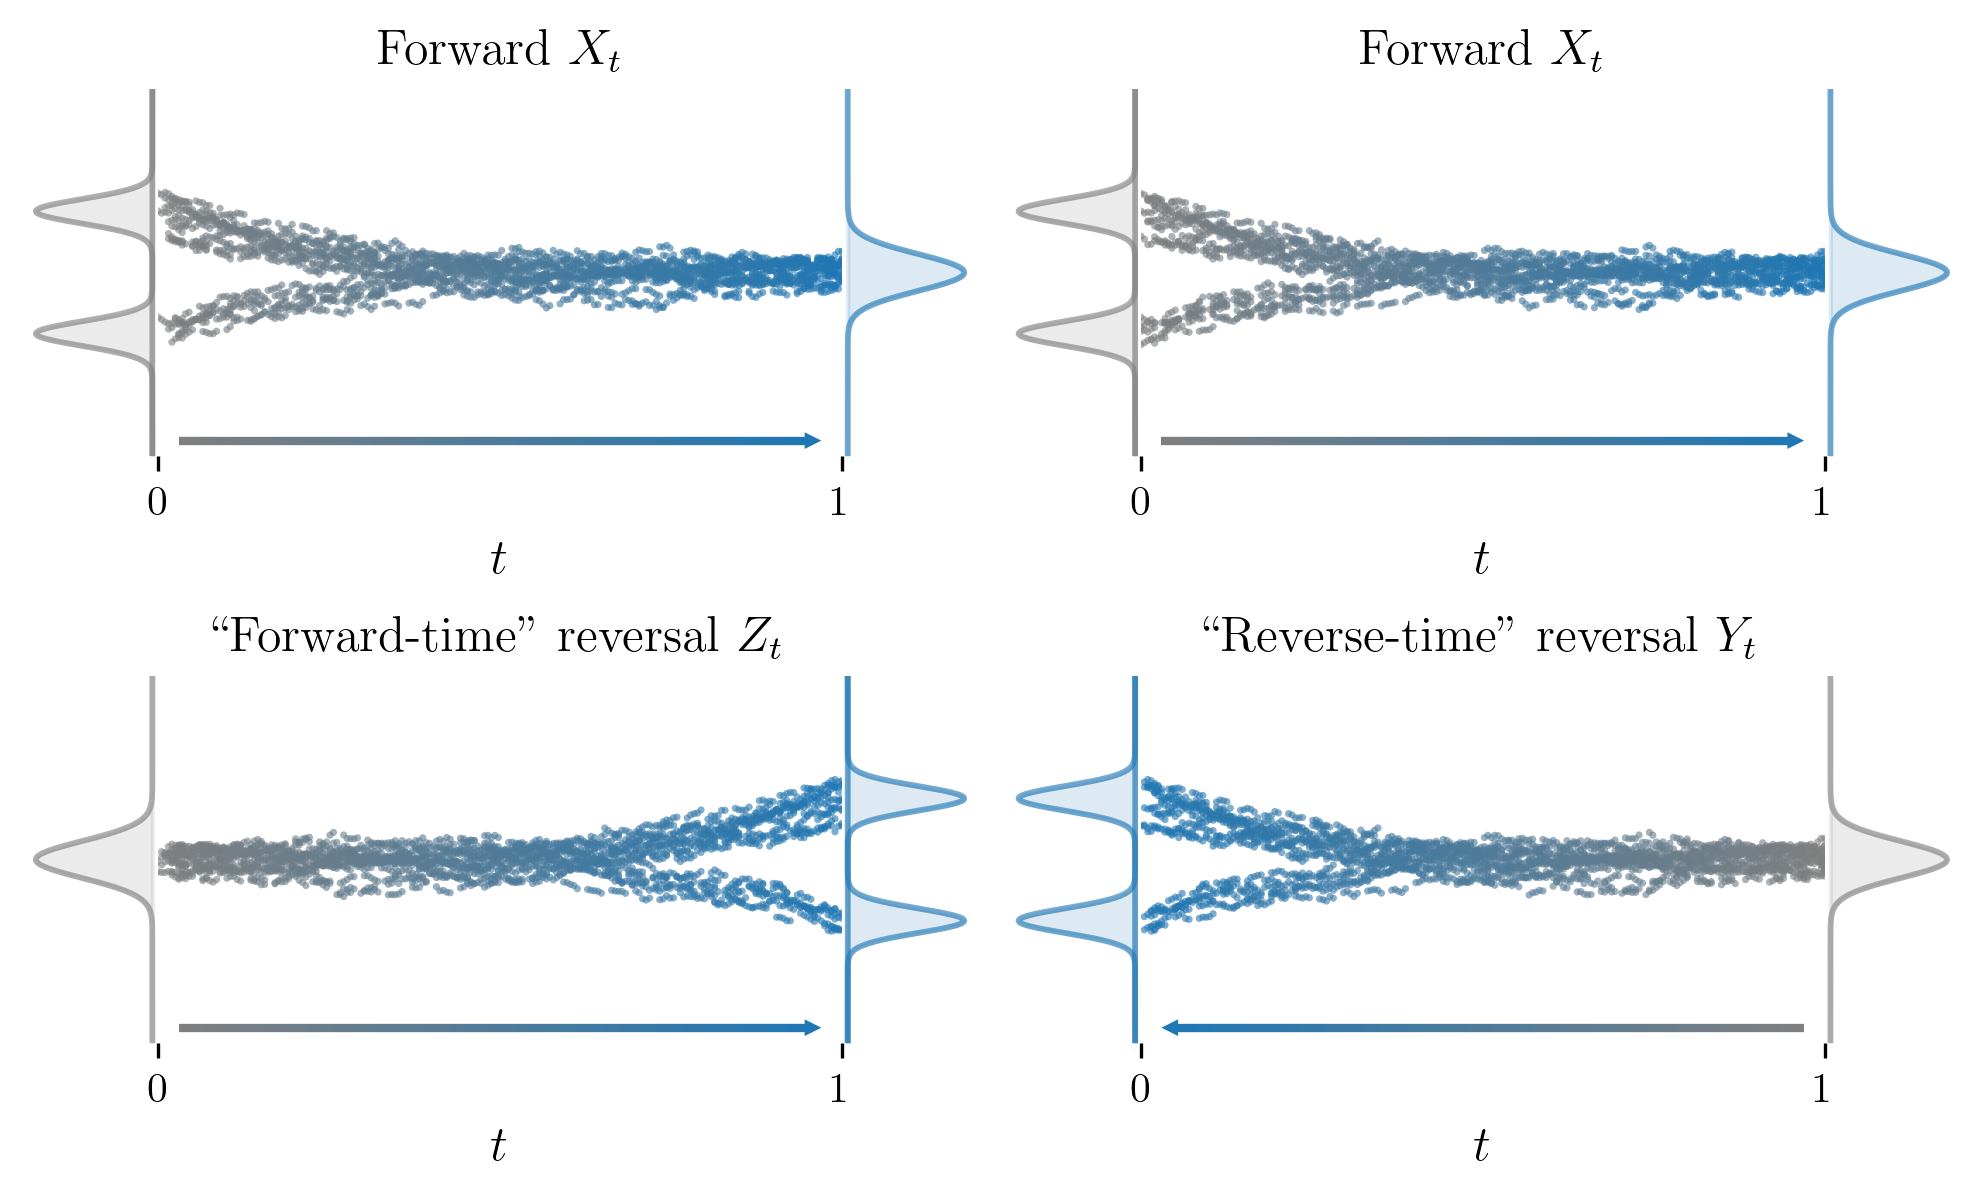

In [114]:
#!/usr/bin/env python3
# ──────────────────────────────────────────────────────────────────────────────
#  time_reversal_figure.py
# ──────────────────────────────────────────────────────────────────────────────
#  Four‑panel schematic:
#       ┌──────────────┬──────────────┐
#       │ Forward      │ Forward      │   (row 0)
# source│ (col‑A)      │ (col‑B)      │target
#       ├──────────────┼──────────────┤
# source│ Andersen‑rev │ Nelson‑rev   │target
#       │ (fwd in t)   │ (bwd in t)   │   (row 1)
#       └──────────────┴──────────────┘
#  pdf strips: source pdf hugs x=0 (left edge)
#              mirror image of target pdf hugs x=1 (right edge)
#  Nelson arrow points right → left; others left → right.
# ──────────────────────────────────────────────────────────────────────────────

from pathlib import Path

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import norm

# -----------------------------------------------------------------------------
# Matplotlib / LaTeX look‑and‑feel  (feel free to comment out LaTeX if needed)
# -----------------------------------------------------------------------------
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
plt.rc("text.latex", preamble=r"\usepackage{amsfonts}\usepackage{amsmath}")

# colour palette
sns_blue, sns_brown = sns.color_palette("tab10")[0], sns.color_palette("tab10")[5]
# grey = "grey"
grey_hex = "#7f7f7f"  # neutral mid‑grey
cmap_gb = LinearSegmentedColormap.from_list("gb", [grey_hex, sns_blue])
cmap_gb_flipped = LinearSegmentedColormap.from_list("gb_flipped", [sns_blue, grey_hex])
# -----------------------------------------------------------------------------
# OU simulation parameters
# -----------------------------------------------------------------------------
theta = 4.0  # mean‑reversion rate
sigma = 1.0  # volatility
T = 200  # time grid points
t = np.linspace(0, 1, T)
dt = 1 / T
n_paths = 20  # number of sample paths to draw


# -----------------------------------------------------------------------------
# Helper to simulate one OU path  X_{t+dt} = X_t + θ(−X_t)dt + σ√dt ξ
# -----------------------------------------------------------------------------
def simulate_ou(x0):
    noise = np.random.randn(T - 1)
    x = np.empty(T)
    x[0] = x0
    for i in range(T - 1):
        x[i + 1] = x[i] + theta * (-x[i]) * dt + sigma * np.sqrt(dt) * noise[i]
    return x


# -----------------------------------------------------------------------------
# Bimodal mixture at t=0   :  N(+2,0.4²) with prob ½  OR  N(−2,0.4²) with prob ½
# -----------------------------------------------------------------------------
def sample_bimodal(n_samples=1):
    modes = np.random.choice([+2, -2], size=n_samples)
    return modes + 0.4 * np.random.randn(n_samples)


# draw sample paths just once
forward_paths = [simulate_ou(sample_bimodal()[0]) for _ in range(n_paths)]
anders_paths = [p[::-1] for p in forward_paths]  # Andersen re‑index

# -----------------------------------------------------------------------------
# Build the 2×6 grid:   0:(main), 1:(pdf), 2 dummy, 3:(main), 4:(pdf), 5 dummy
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(8.27, 4.13), dpi=300)
gs = gridspec.GridSpec(
    nrows=2,
    ncols=7,
    width_ratios=[3, 16, 3, 1, 3, 16, 3],  # last col dummy spacer
    height_ratios=[1, 1],
    wspace=0.0,
    hspace=0.6,
)


# -----------------------------------------------------------------------------
# Gradient helpers
# -----------------------------------------------------------------------------
def _segmentise(xs, ys, step):
    """
    Return Nx2x2 array of segments.
    If step is an integer, segments are taken every *step* points.
    If step is a tuple (seg_len, gap_len), creates segments of length seg_len with gaps of length gap_len.
    """
    if isinstance(step, tuple) and len(step) == 2:
        seg_len, gap_len = step
        segments = []
        i = 0
        while i < len(xs) - seg_len:
            segment = np.stack(
                [
                    np.column_stack([xs[i : i + seg_len - 1], ys[i : i + seg_len - 1]]),
                    np.column_stack([xs[i + 1 : i + seg_len], ys[i + 1 : i + seg_len]]),
                ],
                axis=1,
            )
            segments.append(segment)
            i += seg_len + gap_len
        return np.vstack(segments) if segments else np.empty((0, 2, 2))
    else:
        # Original behavior for integer step
        xs, ys = xs[::step], ys[::step]
        return np.stack(
            [np.column_stack([xs[:-1], ys[:-1]]), np.column_stack([xs[1:], ys[1:]])],
            axis=1,
        )


def gradient_line(ax, xs, ys, *, forward=True, lw=1.5, alpha=1.0, step=10):
    """Solid gradient line."""
    segs = _segmentise(xs, ys, step)
    vals = np.linspace(0, 1, len(segs))
    if not forward:
        vals = 1 - vals
    lc = LineCollection(
        segs,
        cmap=cmap_gb if forward else cmap_gb_flipped,
        norm=plt.Normalize(0, 1),
        linewidths=lw,
        alpha=alpha,
    )
    lc.set_array(vals)
    ax.add_collection(lc)


def gradient_arrow(ax, x0, x1, y, *, forward=True, lw=2.0):
    """
    Horizontal arrow with gradient shaft and blue head.
    """
    xs = np.linspace(x0, x1, 200)
    ys = np.full_like(xs, y)
    gradient_line(ax, xs, ys, forward=forward, lw=lw, alpha=1.0, step=4)

    head_dir = x1 - x0
    head_color = sns_blue
    head = FancyArrowPatch(
        (x1 - 0.02 * head_dir, y),
        (x1, y),
        mutation_scale=10,
        arrowstyle="-|>",
        color=head_color,
        lw=0,
        zorder=3,
    )
    ax.add_patch(head)


def make_panel(row, col_main, col_pdf_s, col_pdf_t):
    ax = fig.add_subplot(gs[row, col_main])
    pdf_s = fig.add_subplot(gs[row, col_pdf_s], sharey=ax)
    pdf_s.set_xticks([])
    pdf_s.set_yticks([])
    for sp in pdf_s.spines.values():
        sp.set_visible(False)
    pdf_t = fig.add_subplot(gs[row, col_pdf_t], sharey=ax)
    pdf_t.set_xticks([])
    pdf_t.set_yticks([])
    for sp in pdf_t.spines.values():
        sp.set_visible(False)
    return ax, pdf_s, pdf_t


# main axes ↓
ax_F1, pdf_F1, pdf_F1_t = make_panel(0, 1, 0, 2)  # forward (column A)
ax_F2, pdf_F2, pdf_F2_t = make_panel(0, 5, 4, 6)  # forward (column B)
ax_A, pdf_A, pdf_A_t = make_panel(1, 1, 0, 2)  # Andersen reverse
ax_N, pdf_N, pdf_N_t = make_panel(1, 5, 4, 6)  # Nelson reverse


# -----------------------------------------------------------------------------
# Density‑strip helper  (source on left, mirror(target) on right)
# -----------------------------------------------------------------------------
def draw_strip(ax_strip, modes, strip_width=1.0, *, side="left"):
    """
    modes : list of (mu, sigma, colour)
    side  : 'left'  -> pdf on left border      (x = pdf)
            'right' -> mirror on right border (x = strip_width - pdf)
    """
    y = np.linspace(-6, 6, 400)
    for mu, sig, col in modes:
        pdf = norm.pdf(y, mu, sig)
        pdf = pdf / pdf.max() * strip_width
        x_coords = pdf if side == "left" else strip_width - pdf
        ax_strip.plot(x_coords, y, color=col, lw=1.4, alpha=0.6)
        ax_strip.fill_betweenx(
            y,
            x_coords,
            0 if side == "left" else strip_width,
            color=col,
            alpha=0.15,
        )
    ax_strip.set_xlim(-0.05, strip_width * 1.05)
    ax_strip.set_xticks([])
    ax_strip.set_yticks([])
    for sp in ax_strip.spines.values():
        sp.set_visible(False)


bimodal_modes = [(+2, 0.4, grey_hex), (-2, 0.4, grey_hex)]
gauss_modes = [(0, 0.6, sns_blue)]

bimodal_modes_flipped = [(2, 0.4, sns_blue), (-2, 0.4, sns_blue)]
gauss_modes_flipped = [(0, 0.6, grey_hex)]
# -----------------------------------------------------------------------------
# --- Plot everything ----------------------------------------------------------
# -----------------------------------------------------------------------------
# 1. Forward paths (row 0, shown twice)


def plot_scattered_path(
    ax, t, path, plot_n=5, skip_n=3, cmap=cmap_gb, alpha=0.6, s=3, flip_cmap=False
):
    """
    Plot a path with scattered points, plotting plot_n points, then skipping skip_n points.
    """
    step = plot_n + skip_n
    for i in range(np.random.randint(0, step), len(t), step):
        idx_to_plot = slice(i, min(i + plot_n, len(t)))
        # If flip_cmap is True, reverse the coloring by using 1-t instead of t
        color_values = 1 - t[idx_to_plot] if flip_cmap else t[idx_to_plot]
        ax.scatter(
            t[idx_to_plot],
            path[idx_to_plot],
            c=cmap(color_values),
            alpha=alpha,
            edgecolor="none",
            s=s,
        )


for path in forward_paths:
    plot_scattered_path(ax_F1, t, path, plot_n=5, skip_n=2)
    plot_scattered_path(ax_F2, t, path, plot_n=5, skip_n=2)


# pdf strips for forward panels
for pdf_ax_s, pdf_ax_t in ((pdf_F1, pdf_F1_t), (pdf_F2, pdf_F2_t)):
    draw_strip(pdf_ax_s, bimodal_modes, side="right")  # source at x=0
    draw_strip(pdf_ax_t, gauss_modes, side="left")  # target mirrored at x=1

# 2. Andersen reverse (row 1, left column – still runs left→right)
for path in anders_paths:
    # idx = slice(None, None, 1)
    # ax_A.plot(t[idx], path[idx], color='grey', ls="--", alpha=.6)
    plot_scattered_path(ax_A, t, path, plot_n=5, skip_n=2)

draw_strip(pdf_A, gauss_modes_flipped, side="right")  # source now Gaussian
draw_strip(pdf_A_t, bimodal_modes_flipped, side="left")  # target mirrored bimodal

# 3. Nelson reverse (row 1, right column – runs right→left)
for path in forward_paths:  # same data as forward
    # idx = slice(None, None, 1)
    # ax_N.plot(t[idx], path[idx], color='grey', ls="--", alpha=.6)  # flip x
    plot_scattered_path(ax_N, t, path, plot_n=5, skip_n=2, flip_cmap=True)

draw_strip(pdf_N, bimodal_modes_flipped, side="right")  # source bimodal
draw_strip(pdf_N_t, gauss_modes_flipped, side="left")  # target mirrored Gaussian

# -----------------------------------------------------------------------------
# --- Axis cosmetics & arrows --------------------------------------------------
# -----------------------------------------------------------------------------
# for ax in [pdf_F1, pdf_A]:
#     ax.set_yticks([-6, 0, 6])

for ax, title in zip(
    [ax_F1, ax_F2, ax_A, ax_N],
    [
        r"Forward $X_t$",
        r"Forward $X_t$",
        r"``Forward-time'' reversal $Z_t$",
        r"``Reverse-time'' reversal $Y_t$",
    ],
):
    ax.set_xlim(0, 1)
    ax.set_ylim(-6, 6)
    # ax.set_xticks([0, 1]); ax.set_yticks([-6, 0, 6])
    ax.set_xticks([0, 1])
    ax.set_xlabel(r"$t$", fontsize=12)
    # ax.set_ylabel(r"$X_t$", fontsize=12)
    ax.set_title(title, fontsize=12)
    for sp in ax.spines.values():
        sp.set_visible(False)

from matplotlib.patches import FancyArrowPatch

# # arrows indicating clock direction
# def add_arrow(ax, right_to_left=True):
#     if right_to_left:
#         ax.annotate("", xy=(0.0, -5.5), xytext=(1.0, -5.5),
#                     arrowprops=dict(arrowstyle="->", lw=1.4))
#     else:
#         ax.annotate("", xy=(1.0, -5.5), xytext=(0.00, -5.5),
#                     arrowprops=dict(arrowstyle="->", lw=1.4))

gradient_arrow(ax_F1, 0.03, 0.97, -5.5, forward=True)
gradient_arrow(ax_F2, 0.03, 0.97, -5.5, forward=True)
gradient_arrow(ax_A, 0.03, 0.97, -5.5, forward=True)
gradient_arrow(ax_N, 0.97, 0.03, -5.5, forward=False)  # backwards

# add_arrow(ax_F1, False); add_arrow(ax_F2, False)
# add_arrow(ax_A , False); add_arrow(ax_N , True)      # Nelson: right→left

plt.tight_layout()

savepath = Path(
    "/Users/shreyaspadhy/Documents/Obsidian Vault/phd-thesis/Chapter3/Figs/"
)

plt.savefig(
    Path(savepath) / "Vector" / "sde_reversal.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.savefig(
    Path(savepath) / "Raster" / "sde_reversal.png",
    format="png",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)

# optional save
# out_dir = Path(".")
# plt.savefig(out_dir / "time_reversal_figure.pdf",   bbox_inches="tight", transparent=True)
# plt.savefig(out_dir / "time_reversal_figure.png",   bbox_inches="tight", dpi=300)

plt.show()

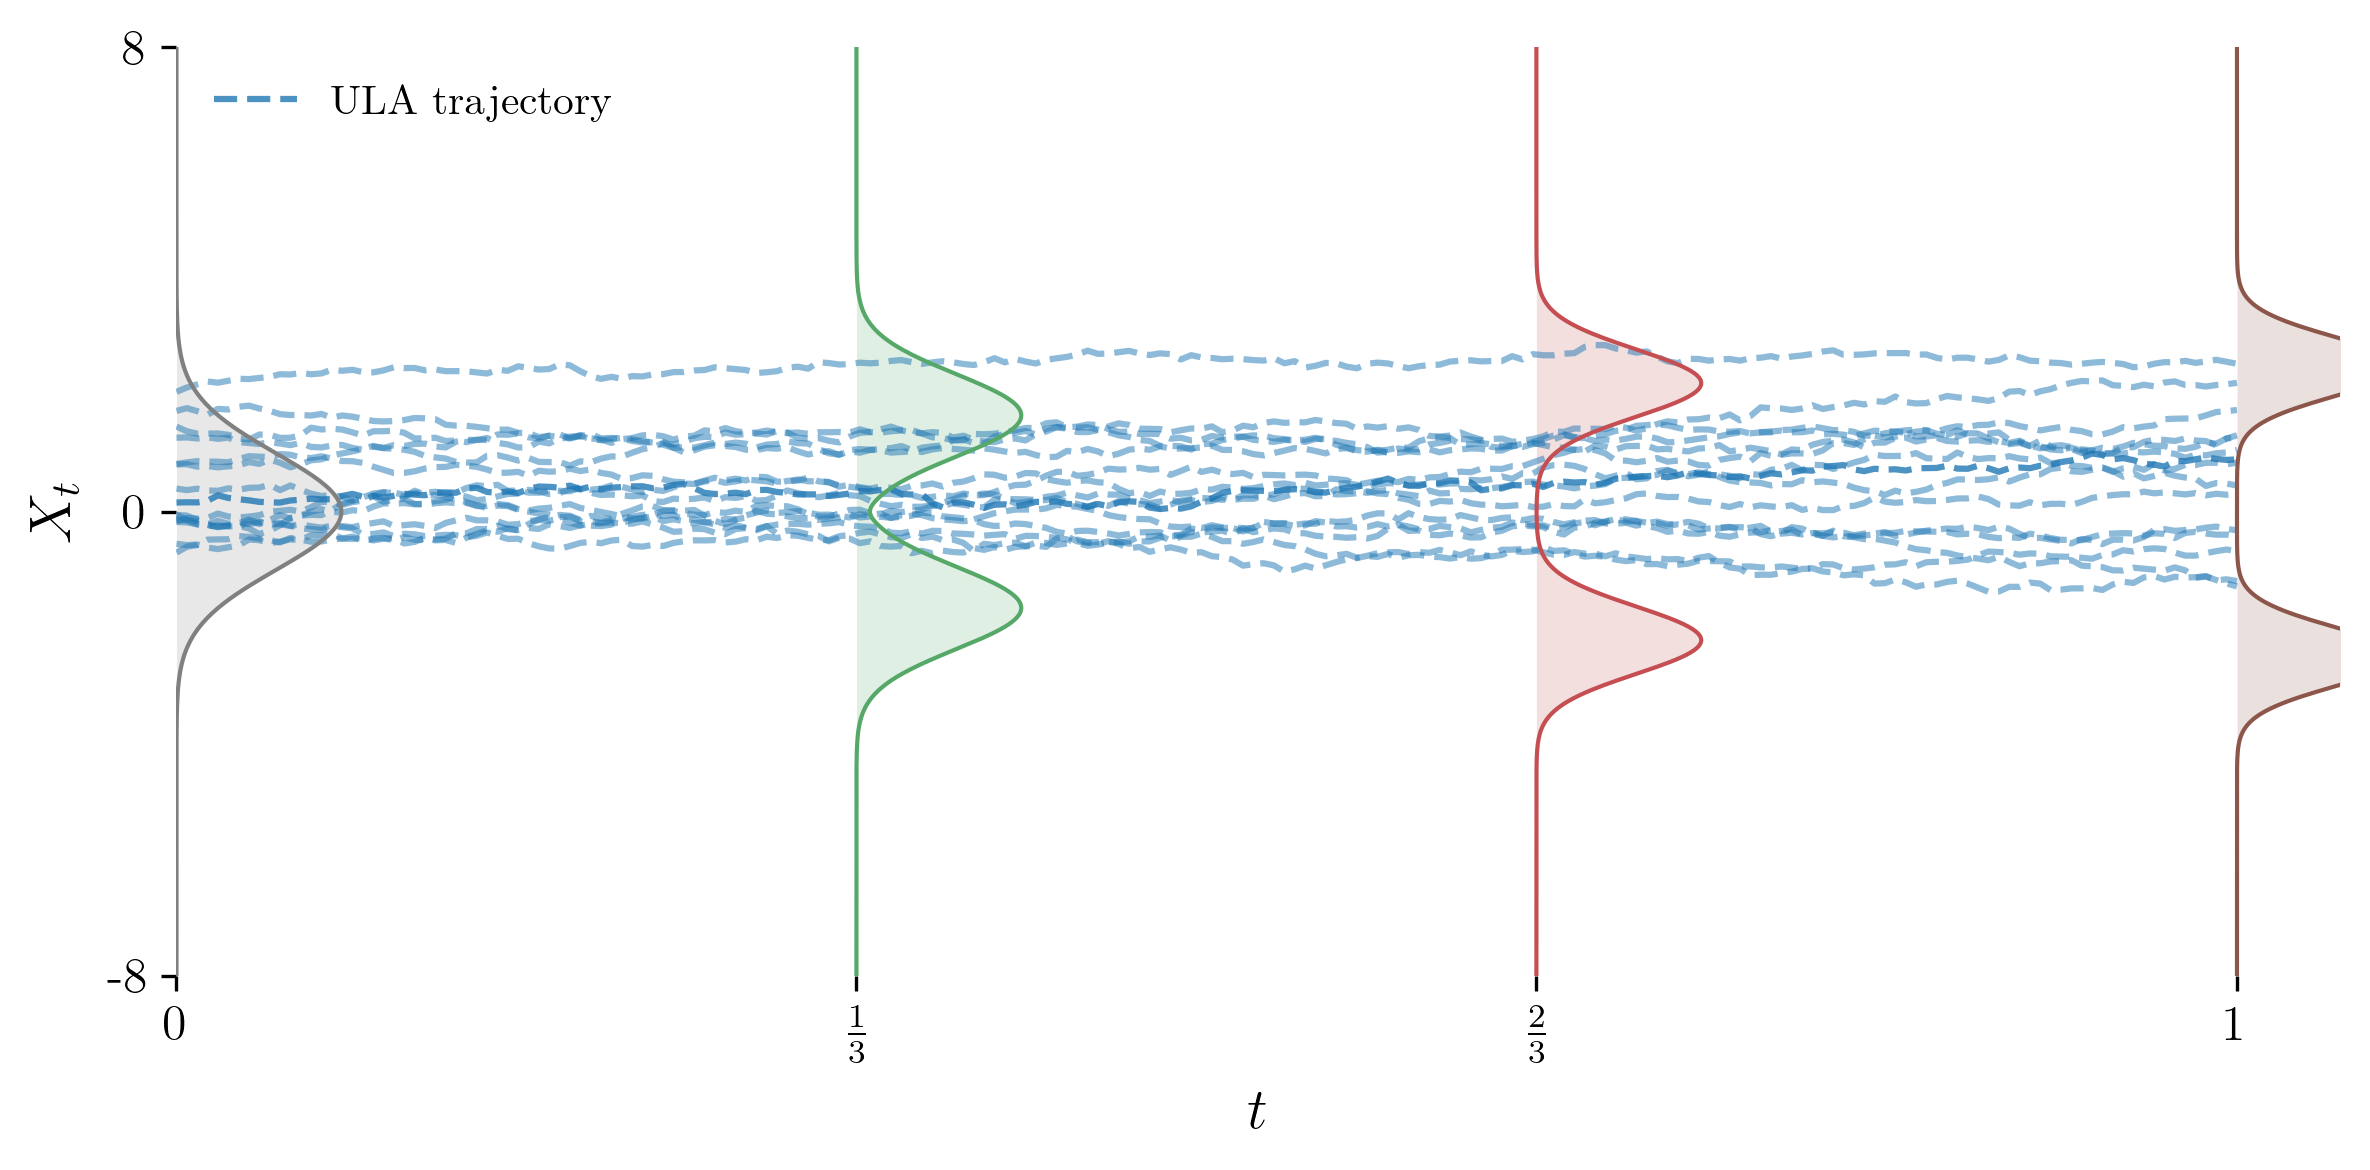